In [1]:
import re
import json
import requests
from typing import Optional

class SenamhiTransformer:
  def __init__(self, base_url: str):
    self.base_url = base_url

  def parse_highcharts_config(self, raw_information: str) -> str:

    raw_information = re.sub(r'/\*.*?\*/', '', raw_information, flags=re.DOTALL)
    raw_information = re.sub(r'//.*?(\n|$)', '', raw_information)

    raw_information = re.sub(r'([{,])\s*([a-zA-Z_][a-zA-Z0-9_]*)\s*:', r'\1"\2":', raw_information)

    raw_information = re.sub(r',\s*}', '}', raw_information)
    raw_information = re.sub(r',\s*]', ']', raw_information)

    raw_information = re.sub(r"'([^']*)'", r'"\1"', raw_information)
    return raw_information

  def get_json_information_from_bytes(self, raw_bytes_information):

      if isinstance(raw_bytes_information, bytes):
        print("Transform bytes to string", raw_bytes_information)
        try:
          raw_bytes_information = raw_bytes_information.decode('utf-8')
        except Exception as e:
          raw_bytes_information = raw_bytes_information.decode('utf-8', errors='replace')


      current_match = re.search(r"Highcharts\.chart\('container',\s*(\{.*\})\);", raw_bytes_information, re.DOTALL)
      diccionario_str = ""

      if current_match:
          diccionario_str = current_match.group(1)
          diccionario_str = self.parse_highcharts_config(diccionario_str)
          try:
              config = json.loads(diccionario_str)
              print("✅ Éxito!")

              time_line = config['xAxis']['categories']
              data = config['series'][0]['data']

              return time_line, data

          except json.JSONDecodeError as e:
              print(f"Error en posición {e.pos}: {e.msg}")
              print(f"Fragmento problemático: ...{diccionario_str[e.pos-50:e.pos+50]}...")
              raise e


  def get_variable_data(
      self, station_id: str, variable_name: str,
      start_period: Optional[str] = '01/03/2025', end_period: Optional[str] = '01/03/2026'
  ):
    query_params = {
      "estacion": station_id,
      "cont": variable_name,
      "f1": start_period,
      "f2": end_period
    }
    try:
      print(f"Obteniendo valores para {station_id} y {variable_name}")
      raw_response = requests.get(self.base_url, params=query_params).content
      print("Exito al invocar al servicio")
      raw_response = self.get_json_information_from_bytes(raw_response)

      return raw_response
    except Exception as e:
      print(f"Error to get information to {station_id} and {variable_name} con detalle {e}")
      raise e


# Definiendo constantes

In [2]:
SENAMHI_URL = 'https://www.senamhi.gob.pe/site/sea/www/site/sea/graficas/dato_hora_met.php'
senamhi_transformer = SenamhiTransformer(SENAMHI_URL)
##exist data '112265','111287' , '111286' , '112265'  ,'112193' ,'112233' ,'112277' ,'112181'
stations_ids = ['112265','111287' , '111286' , '112265'  ,'112193' ,'112233' ]
var_names = ['VELO', 'HUME', 'TEMP']
all_data = {}
datetime_columns = []

In [3]:
from typing import List
import pandas as pd
from enum import Enum

class MapperSenamhiEndpointEnum(Enum):
  SOURCE = 'https://www.senamhi.gob.pe/site/sea/www/site/sea/graficas/dato_hora_met.php'
  TARGET = 'https://www.senamhi.gob.pe/site/sea/www/site/sea/graficas/dato_hora.php'

stations_ids = ['112265','111287' , '111286' , '112265'  ,'112193' ,'112233']

def get_meteorological_variables_data(station_id:str, var_names:List[str], endpoint: str):
  all_predicted_data = {}

  print("ajajaja", station_id, var_names,  endpoint)
  for var_name in var_names:
    senamhi_transformer = SenamhiTransformer(endpoint)
    var_time_line, variable_values = senamhi_transformer.get_variable_data(station_id, var_name)

    all_predicted_data[f'READING_DATETIME_{var_name}'] = var_time_line
    all_predicted_data[var_name] = variable_values
    all_predicted_data['STATION_ID'] = [station_id]*len(variable_values)

  return all_predicted_data


def get_meteorological_data(station_id: str):

  source_var_names = ['VELO', 'HUME', 'TEMP']
  target_var_names = ['N_PM25']

  source_variable_data = get_meteorological_variables_data(station_id, source_var_names, MapperSenamhiEndpointEnum.SOURCE.value)
  target_variable_data = get_meteorological_variables_data(station_id, target_var_names, MapperSenamhiEndpointEnum.TARGET.value)

  source_df = pd.DataFrame(source_variable_data)
  target_df = pd.DataFrame(target_variable_data)

  source_df['READING_DATETIME'] = pd.to_datetime(source_df['READING_DATETIME_VELO'], format='%d/%m/%Y%H:%M:')
  target_df['READING_DATETIME_TARGET'] = pd.to_datetime(target_df['READING_DATETIME_N_PM25'], format='%d/%m/%Y%H:%M:')

  return pd.merge(source_df[[
    *source_var_names, 'STATION_ID', 'READING_DATETIME'
  ]], target_df[[
    *target_var_names, 'READING_DATETIME_TARGET'
  ]], left_on='READING_DATETIME', right_on='READING_DATETIME_TARGET', how='inner')

def get_meteorological_data_by_stations_id(station_ids: List[str]) -> pd.DataFrame:
  meteorological_df = pd.DataFrame({
    'VELO': pd.Series(dtype='float'),
    'HUME': pd.Series(dtype='float'),
    'TEMP': pd.Series(dtype='float'),
    'STATION_ID': pd.Series(dtype='str'),
    'READING_DATETIME': pd.Series(dtype='datetime64[ns]')
})
  lista_dfs = []
  for station_id in station_ids:

    station_meteorological_df= get_meteorological_data(station_id)

    if not station_meteorological_df.empty:
        lista_dfs.append(station_meteorological_df)

  meteorological_df = pd.concat(lista_dfs, ignore_index=True)
  return meteorological_df




In [ ]:
meteorological_df = get_meteorological_data_by_stations_id(stations_ids)

ajajaja 112265 ['VELO', 'HUME', 'TEMP'] https://www.senamhi.gob.pe/site/sea/www/site/sea/graficas/dato_hora_met.php
Obteniendo valores para 112265 y VELO
Exito al invocar al servicio
Transform bytes to string b'\r\n<!DOCTYPE HTML>\r\n<html>\r\n    <head>\r\n        <meta http-equiv="Content-Type" content="text/html; charset=utf-8">\r\n        <title>SENAMHI - SEA</title>\r\n\r\n        <style type="text/css">\r\n\r\n        </style>\r\n    </head>\r\n    <body>\r\n        <script src="code/highcharts.js"></script>\r\n        <script src="code/modules/exporting.js"></script>\r\n\r\n        <div id="container" style="min-width: 310px; height: 580px; margin: 0 auto"></div>\r\n\r\n\r\n        <script type="text/javascript">\r\n\r\n            Highcharts.chart(\'container\', {\r\n                chart: {\r\n                    type: \'line\'\r\n                },\r\n                title: {\r\n                    text: \'ESTACI\\u00D3N: SAN MARTIN DE PORRES (SMP) - Lima Norte\'\r\n         

/tmp/ipykernel_1674/4050755593.py:62: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  meteorological_df = pd.concat(lista_dfs, ignore_index=True)


In [ ]:
meteorological_df

,VELO,HUME,TEMP,STATION_ID,READING_DATETIME,N_PM25,READING_DATETIME_TARGET
0,1.7,86.4,23.4,112265,2025-03-01 00:00:00,16.4,2025-03-01 00:00:00
1,1.1,88.2,23.1,112265,2025-03-01 01:00:00,12.8,2025-03-01 01:00:00
2,1.0,89.3,22.9,112265,2025-03-01 02:00:00,13.6,2025-03-01 02:00:00
3,0.4,94.7,22.6,112265,2025-03-01 03:00:00,13.3,2025-03-01 03:00:00
4,0.9,98.3,22.6,112265,2025-03-01 04:00:00,14.8,2025-03-01 04:00:00
...,...,...,...,...,...,...,...
50894,1.3,78.0,22.9,112233,2026-03-01 19:00:00,4.4,2026-03-01 19:00:00
50895,1.5,83.0,21.8,112233,2026-03-01 20:00:00,3.5,2026-03-01 20:00:00
50896,1.3,85.0,21.4,112233,2026-03-01 21:00:00,3.1,2026-03-01 21:00:00
50897,1.0,86.0,21.5,112233,2026-03-01 22:00:00,3.7,2026-03-01 22:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

#Saving data

In [ ]:
drive_file_path = '/content/drive/MyDrive/training_data_v3.parquet'

In [ ]:
meteorological_df.to_parquet(drive_file_path)

#Reading data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
drive_file_path = '/content/drive/MyDrive/training_data_v2.parquet'

In [ ]:
import pandas as pd

# Read the parquet file into a pandas DataFrame
training_data = pd.read_parquet(drive_file_path)
meteorological_df = training_data
# Display the first 5 rows of the DataFrame
display(training_data.head())

,VELO,HUME,TEMP,STATION_ID,READING_DATETIME,N_PM25,READING_DATETIME_TARGET
0,1.0,93.2,17.0,112265,2025-10-01 00:00:00,20.0,2025-10-01 00:00:00
1,1.1,95.4,16.9,112265,2025-10-01 01:00:00,20.2,2025-10-01 01:00:00
2,1.0,95.5,16.9,112265,2025-10-01 02:00:00,21.3,2025-10-01 02:00:00
3,1.0,98.4,16.8,112265,2025-10-01 03:00:00,20.3,2025-10-01 03:00:00
4,1.0,100.0,16.7,112265,2025-10-01 04:00:00,18.6,2025-10-01 04:00:00


#Analisis de la Data

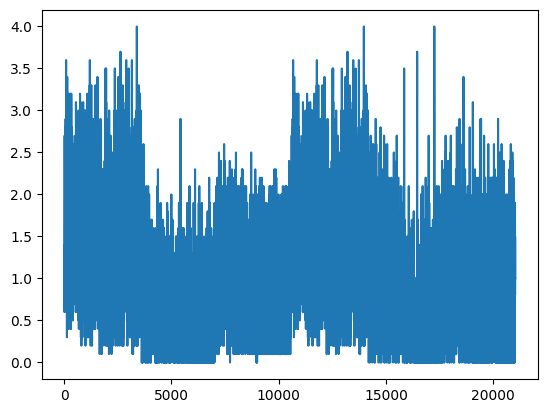

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

meteorological_df['VELO'].plot()
plt.show()



In [ ]:
meteorological_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50899 entries, 0 to 50898
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   VELO                     50898 non-null  float64       
 1   HUME                     50898 non-null  float64       
 2   TEMP                     50897 non-null  float64       
 3   STATION_ID               50899 non-null  object        
 4   READING_DATETIME         50899 non-null  datetime64[ns]
 5   N_PM25                   40426 non-null  float64       
 6   READING_DATETIME_TARGET  50899 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(4), object(1)
memory usage: 2.7+ MB


#Feature Engineering

In [ ]:
from typing import Tuple, List
import numpy as np

def create_temporal_features(df, column_name: str) -> Tuple[pd.DataFrame, List[str]] :
    temporal_names = ['hour', 'dayofweek', 'month', 'dayofyear', 'year']
    created_features = [ f'{temporal_name}_{column_name}' for temporal_name in temporal_names]

    df[created_features[0]] = df[column_name].dt.hour
    df[created_features[1]] = df[column_name].dt.dayofweek
    df[created_features[2]] = df[column_name].dt.month
    df[created_features[3]] = df[column_name].dt.dayofyear
    df[created_features[4]] = df[column_name].dt.year
    return df, created_features

def create_cyclic_features(df, col, period):
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / period)
    df[f'{col}_cos'] = np.cos(2* np.pi * df[col] / period)
    return df

def create_lag_features(df, column, lags):
    for lag in lags:
        df[f'{column}_lag_{lag}'] = df[column].shift(lag)
    return df

def create_rolling_features(df, column, windows):
    for window in windows:
        df[f'{column}_rolling_mean_{window}'] = df[column].rolling(window=window).mean()
        df[f'{column}_rolling_std_{window}'] = df[column].rolling(window=window).std()
    return df

#Creando Variables Cíclicas

In [ ]:
merged_df, created_temporal_feature = create_temporal_features(meteorological_df, 'READING_DATETIME')
MAPPER_CYCLIC_VALUE = {
    'hour': 24,
    'dayofweek': 7,
    'month': 12
}

for mapper_cyclic_key in MAPPER_CYCLIC_VALUE:
  filtered_colum = [ tmp_el for tmp_el in created_temporal_feature if tmp_el.startswith(mapper_cyclic_key) ]
  if len(filtered_colum) > 0:
    print(f"Creando variables cíclica para {filtered_colum[0]} con el periodo de {MAPPER_CYCLIC_VALUE[mapper_cyclic_key]}")
    merged_df = create_cyclic_features(merged_df, filtered_colum[0], MAPPER_CYCLIC_VALUE[mapper_cyclic_key])


Creando variables cíclica para hour_READING_DATETIME con el periodo de 24
Creando variables cíclica para dayofweek_READING_DATETIME con el periodo de 7
Creando variables cíclica para month_READING_DATETIME con el periodo de 12


In [ ]:
meteorological_df.columns

Index(['VELO', 'HUME', 'TEMP', 'STATION_ID', 'READING_DATETIME', 'N_PM25',
       'READING_DATETIME_TARGET', 'hour_READING_DATETIME',
       'dayofweek_READING_DATETIME', 'month_READING_DATETIME',
       'dayofyear_READING_DATETIME', 'year_READING_DATETIME',
       'hour_READING_DATETIME_sin', 'hour_READING_DATETIME_cos',
       'dayofweek_READING_DATETIME_sin', 'dayofweek_READING_DATETIME_cos',
       'month_READING_DATETIME_sin', 'month_READING_DATETIME_cos'],
      dtype='object')

#Agregando LAG a las variables

In [ ]:
lags_pm25 = [1, 2, 24]
lags_weather = [1, 24]

WEATHER_FEATURES = ['VELO', 'HUME', 'TEMP']
TARGET_FEATURES =  ['N_PM25']

for col in TARGET_FEATURES:
    meteorological_df = create_lag_features(meteorological_df, col, lags_pm25)

for col in WEATHER_FEATURES:
    meteorological_df = create_lag_features(meteorological_df, col, lags_weather)

windows_rolling = [6, 24]
for col in WEATHER_FEATURES + TARGET_FEATURES:
    meteorological_df = create_rolling_features(meteorological_df, col, windows_rolling)

In [ ]:
meteorological_df['VELO_SQ'] = meteorological_df['VELO']**2
meteorological_df['VELO_INV'] = 1 / (meteorological_df['VELO'] + 1e-6)

In [ ]:
meteorological_df.columns

Index(['VELO', 'HUME', 'TEMP', 'STATION_ID', 'READING_DATETIME', 'N_PM25',
       'READING_DATETIME_TARGET', 'hour_READING_DATETIME',
       'dayofweek_READING_DATETIME', 'month_READING_DATETIME',
       'dayofyear_READING_DATETIME', 'year_READING_DATETIME',
       'hour_READING_DATETIME_sin', 'hour_READING_DATETIME_cos',
       'dayofweek_READING_DATETIME_sin', 'dayofweek_READING_DATETIME_cos',
       'month_READING_DATETIME_sin', 'month_READING_DATETIME_cos',
       'N_PM25_lag_1', 'N_PM25_lag_2', 'N_PM25_lag_24', 'VELO_lag_1',
       'VELO_lag_24', 'HUME_lag_1', 'HUME_lag_24', 'TEMP_lag_1', 'TEMP_lag_24',
       'VELO_rolling_mean_6', 'VELO_rolling_std_6', 'VELO_rolling_mean_24',
       'VELO_rolling_std_24', 'HUME_rolling_mean_6', 'HUME_rolling_std_6',
       'HUME_rolling_mean_24', 'HUME_rolling_std_24', 'TEMP_rolling_mean_6',
       'TEMP_rolling_std_6', 'TEMP_rolling_mean_24', 'TEMP_rolling_std_24',
       'N_PM25_rolling_mean_6', 'N_PM25_rolling_std_6',
       'N_PM25_rolling_m

#Definiendo variables e inferencias

In [ ]:
meteorological_df = meteorological_df.dropna()
TARGET_COLUMNS = ['N_PM25']
FEATURES_COLUMNS = [col for col in merged_df.columns if ( col not in TARGET_COLUMNS) and not ( col.startswith('READING_DATETIME') or col.startswith('READING_DATETIME_') or col.startswith('STATION_ID'))  ]

X = meteorological_df[FEATURES_COLUMNS]
y = meteorological_df[TARGET_COLUMNS]

In [ ]:
X

,VELO,HUME,TEMP,hour_READING_DATETIME,dayofweek_READING_DATETIME,month_READING_DATETIME,dayofyear_READING_DATETIME,year_READING_DATETIME,hour_READING_DATETIME_sin,hour_READING_DATETIME_cos,...,TEMP_rolling_mean_6,TEMP_rolling_std_6,TEMP_rolling_mean_24,TEMP_rolling_std_24,N_PM25_rolling_mean_6,N_PM25_rolling_std_6,N_PM25_rolling_mean_24,N_PM25_rolling_std_24,VELO_SQ,VELO_INV
24,1.6,91.0,17.1,0,3,10,275,2025,0.000000,1.000000,...,17.600000,0.334664,18.145833,1.324675,22.900000,4.541806,24.079167,6.088191,2.56,0.625000
25,1.3,93.2,17.0,1,3,10,275,2025,0.258819,0.965926,...,17.433333,0.344480,18.150000,1.320738,23.966667,3.477739,24.208333,6.034965,1.69,0.769230
26,1.3,99.7,16.8,2,3,10,275,2025,0.500000,0.866025,...,17.283333,0.397073,18.145833,1.325003,25.483333,1.857328,24.441667,6.025880,1.69,0.769230
27,1.3,100.0,16.6,3,3,10,275,2025,0.707107,0.707107,...,17.083333,0.386868,18.137500,1.334431,26.533333,2.844410,24.887500,6.101483,1.69,0.769230
28,1.5,100.0,16.4,4,3,10,275,2025,0.866025,0.500000,...,16.866667,0.332666,18.125000,1.349799,27.266667,3.798245,25.475000,6.148400,2.25,0.666666
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21022,1.3,78.0,22.9,19,6,3,60,2026,-0.965926,0.258819,...,25.066667,1.557776,23.275000,2.426708,5.500000,1.550484,8.175000,2.635584,1.69,0.769230
21023,1.5,83.0,21.8,20,6,3,60,2026,-0.866025,0.500000,...,24.216667,1.738294,23.270833,2.429256,4.866667,1.440370,7.866667,2.733952,2.25,0.666666
21024,1.3,85.0,21.4,21,6,3,60,2026,-0.707107,0.707107,...,23.316667,1.517124,23.283333,2.418348,4.133333,0.816497,7.683333,2.901973,1.69,0.769230
21025,1.0,86.0,21.5,22,6,3,60,2026,-0.500000,0.866025,...,22.733333,1.409492,23.258333,2.434162,3.866667,0.588784,7.358333,2.892707,1.00,0.999999


In [ ]:
y

,N_PM25
24,16.1
25,15.1
26,13.6
27,16.4
28,15.2
...,...
50894,4.4
50895,3.5
50896,3.1
50897,3.7


#Entrenamiento

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib

n_splits = 10
tscv = TimeSeriesSplit(n_splits=n_splits)


print(f"\nUsando TimeSeriesSplit con {n_splits} splits para validación cruzada.")

# Listas para almacenar las métricas de cada fold
rmse_scores = []
mae_scores = []
r2_scores = []

# Bucle de validación cruzada
for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    print(f"--- Fold {fold+1}/{n_splits} ---")

    # Dividir datos para este fold
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Para el early stopping, necesitamos un conjunto de validación.
    # Tomamos una porción del final de X_train como validación.
    # Asegurarnos de que el conjunto de validación no sea demasiado pequeño.
    val_split_ratio = 0.2 # 20% de X_train para validación
    val_idx = int(len(X_train) * (1 - val_split_ratio))

    X_train_split, X_val = X_train.iloc[:val_idx], X_train.iloc[val_idx:]
    y_train_split, y_val = y_train.iloc[:val_idx], y_train.iloc[val_idx:]

    print(f"  Tamaño X Train (fold): {X_train_split.shape[0]}, Val (fold): {X_val.shape[0]}, Test (fold): {X_test.shape[0]}")
    print(f"  Tamaño y Train (fold): {y_train_split.shape[0]}, Val (fold): {y_val.shape[0]}, Test (fold): {y_test.shape[0]}")

    # Inicializar y entrenar el modelo XGBoost
    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=2590,
        learning_rate=0.035648277949081186,
        max_depth=9,
        subsample=0.9733121035675474,
        colsample_bytree=0.8497416192535173,
        random_state=39,
        n_jobs=-1,
        gamma=0.295633685837714,
        reg_alpha=0.4368808744336672,
        reg_lambda=2.182549739351831
    )

    model.fit(X_train_split, y_train_split,
              eval_set=[(X_val, y_val)],
              verbose=False) # Poner a True para ver el progreso de cada fold

    # Realizar predicciones en el conjunto de prueba de este fold
    y_pred = model.predict(X_test)

    # Calcular métricas para este fold
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"  Resultados Fold {fold+1}: RMSE={rmse:.2f}, MAE={mae:.2f}, R²={r2:.2f}")

    # Almacenar métricas
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)

# --- 5. Evaluación General (Promedio de los Folds) ---

print("\n--- Resultados Generales (Promedio de Folds) ---")
mean_rmse = np.mean(rmse_scores)
mean_mae = np.mean(mae_scores)
mean_r2 = np.mean(r2_scores)

print(f"Promedio RMSE: {mean_rmse:.2f}")
print(f"Promedio MAE: {mean_mae:.2f}")
print(f"Promedio R²: {mean_r2:.2f}")

# --- Análisis de Importancia de Características (Opcional: se puede promediar o mostrar la del último fold) ---
# Para este ejemplo, mostraremos la importancia del último modelo entrenado.
# Si necesitas un promedio de importancias, tendrías que almacenarlas y promediarlas.

print("\nImportancia de las características (último fold):")
feature_importances = pd.DataFrame({
    'feature': FEATURES_COLUMNS,
    'importance': model.feature_importances_ # Usar el modelo del último fold
})
feature_importances = feature_importances.sort_values('importance', ascending=False)

N = 20
print(feature_importances.head(N))

plt.figure(figsize=(12, 8))
plt.barh(feature_importances['feature'][:N], feature_importances['importance'][:N])
plt.xlabel("Importancia")
plt.title("Importancia de las Características (Último Fold)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# --- Visualización de Predicciones (Opcional: graficar un solo fold o el promedio) ---
# Para visualizar, podríamos graficar las predicciones del último fold,
# ya que es el que tiene acceso a más datos históricos para el entrenamiento.
plt.figure(figsize=(15, 7))
plt.plot(y_test.index, y_test, label='Real (Último Fold)', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Predicción (Último Fold)', alpha=0.7)
plt.title('Predicción vs. Valor Real (Último Fold de Prueba)')
plt.xlabel('Fecha/Hora')
plt.ylabel('PM2.5')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Usando TimeSeriesSplit con 10 splits para validación cruzada.


NameError: name 'X' is not defined


Usando TimeSeriesSplit con 10 splits para validación cruzada.
--- Fold 1/10 ---
  Tamaño X Train (fold): 2801, Val (fold): 701, Test (fold): 3498
  Tamaño y Train (fold): 2801, Val (fold): 701, Test (fold): 3498
  Resultados Fold 1: RMSE=4.95, MAE=3.33, R²=0.73
--- Fold 2/10 ---
  Tamaño X Train (fold): 5600, Val (fold): 1400, Test (fold): 3498
  Tamaño y Train (fold): 5600, Val (fold): 1400, Test (fold): 3498
  Resultados Fold 2: RMSE=10.67, MAE=6.01, R²=0.66
--- Fold 3/10 ---
  Tamaño X Train (fold): 8398, Val (fold): 2100, Test (fold): 3498
  Tamaño y Train (fold): 8398, Val (fold): 2100, Test (fold): 3498
  Resultados Fold 3: RMSE=33.17, MAE=7.74, R²=0.18
--- Fold 4/10 ---
  Tamaño X Train (fold): 11196, Val (fold): 2800, Test (fold): 3498
  Tamaño y Train (fold): 11196, Val (fold): 2800, Test (fold): 3498
  Resultados Fold 4: RMSE=8.29, MAE=4.14, R²=0.67
--- Fold 5/10 ---
  Tamaño X Train (fold): 13995, Val (fold): 3499, Test (fold): 3498
  Tamaño y Train (fold): 13995, Val (fold

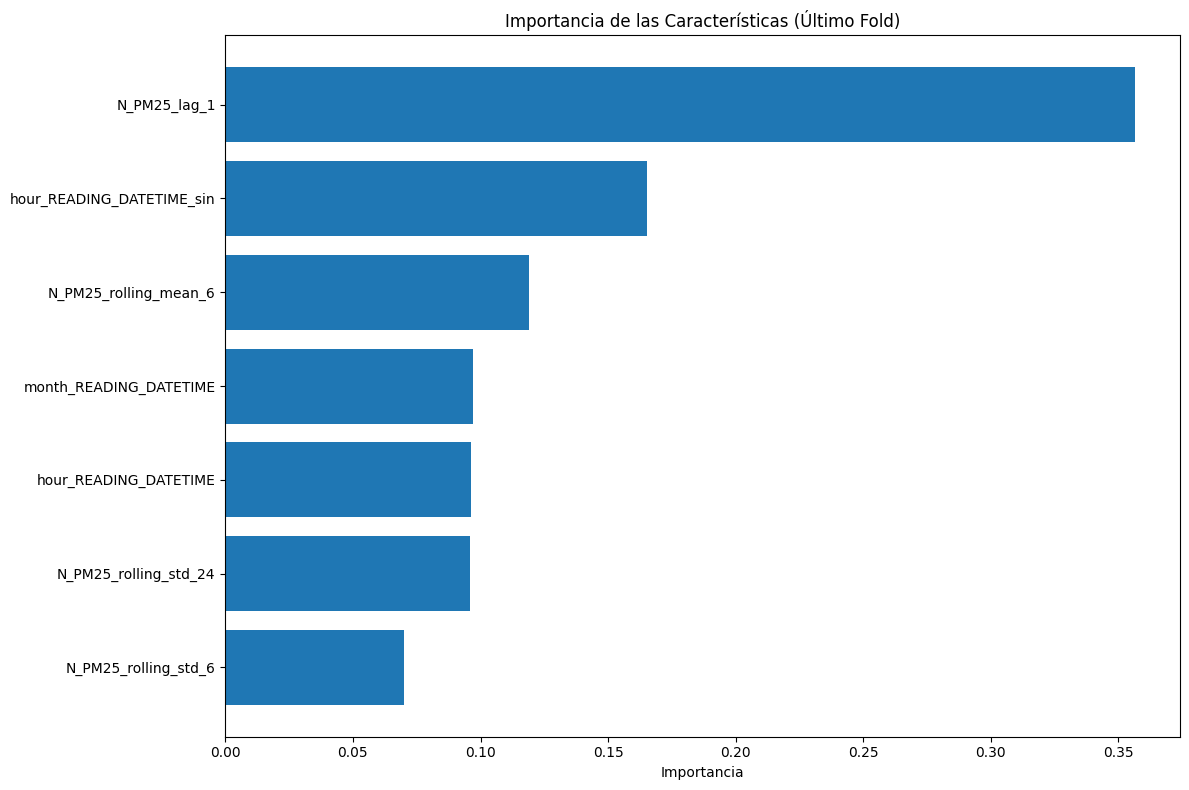

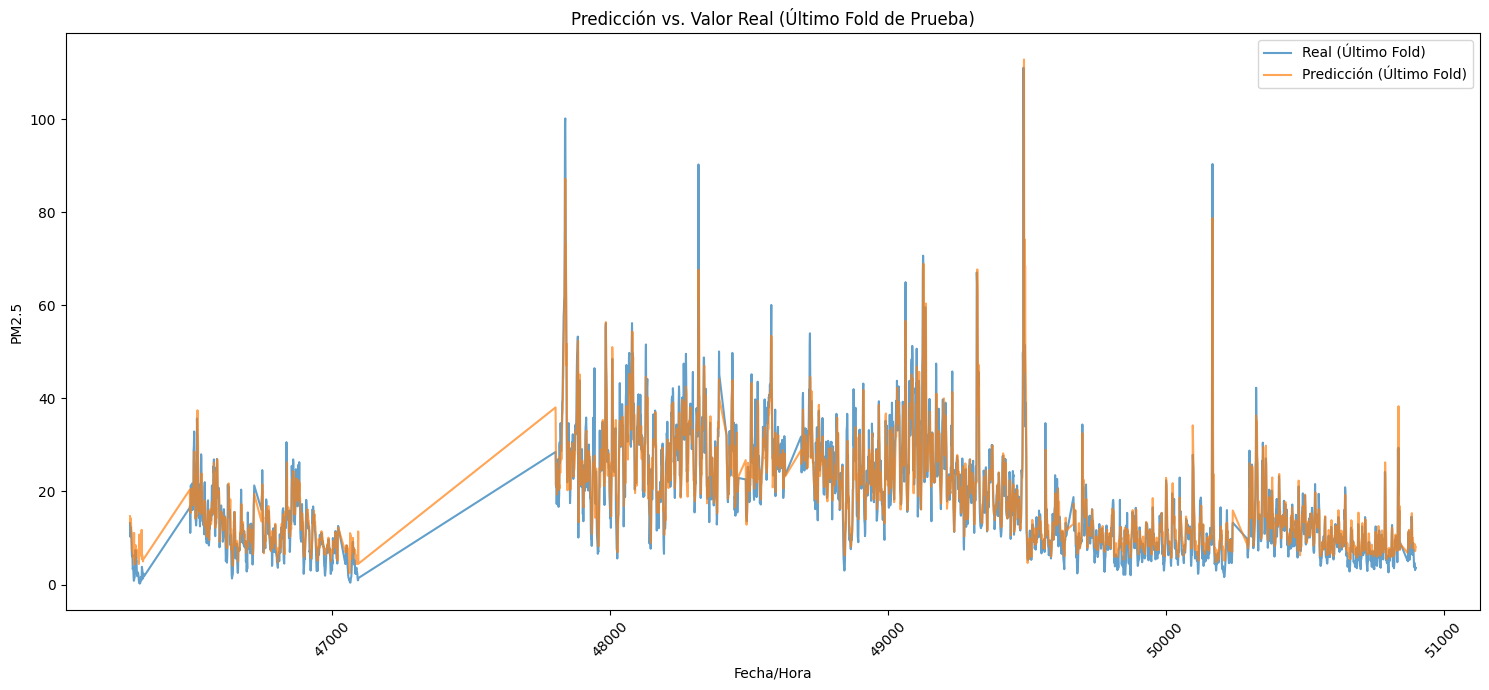

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib

n_splits = 10
tscv = TimeSeriesSplit(n_splits=n_splits)


print(f"\nUsando TimeSeriesSplit con {n_splits} splits para validación cruzada.")

# Listas para almacenar las métricas de cada fold
rmse_scores = []
mae_scores = []
r2_scores = []

LIMITED_FEATURES = ['N_PM25_lag_1', 'N_PM25_rolling_std_24', 'N_PM25_rolling_mean_6', 'hour_READING_DATETIME_sin', 'N_PM25_rolling_std_6', 'hour_READING_DATETIME', 'month_READING_DATETIME']

X_limited = X[LIMITED_FEATURES]
y_limited = y

# Bucle de validación cruzada
for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    print(f"--- Fold {fold+1}/{n_splits} ---")

    # Dividir datos para este fold
    X_train, X_test = X_limited.iloc[train_index], X_limited.iloc[test_index]
    y_train, y_test = y_limited.iloc[train_index], y_limited.iloc[test_index]

    # Para el early stopping, necesitamos un conjunto de validación.
    # Tomamos una porción del final de X_train como validación.
    # Asegurarnos de que el conjunto de validación no sea demasiado pequeño.
    val_split_ratio = 0.2 # 20% de X_train para validación
    val_idx = int(len(X_train) * (1 - val_split_ratio))

    X_train_split, X_val = X_train.iloc[:val_idx], X_train.iloc[val_idx:]
    y_train_split, y_val = y_train.iloc[:val_idx], y_train.iloc[val_idx:]

    print(f"  Tamaño X Train (fold): {X_train_split.shape[0]}, Val (fold): {X_val.shape[0]}, Test (fold): {X_test.shape[0]}")
    print(f"  Tamaño y Train (fold): {y_train_split.shape[0]}, Val (fold): {y_val.shape[0]}, Test (fold): {y_test.shape[0]}")

    # Inicializar y entrenar el modelo XGBoost
    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=1027,
        learning_rate=0.041648277949081186,
        max_depth=6,
        subsample=0.9533121035675474,
        colsample_bytree=0.8497416192535173,
        random_state=42,
        n_jobs=-1,
        gamma=0.295633685837714,
        reg_alpha=0.4368808744336672,
        reg_lambda=2.182549739351831
    )

    model.fit(X_train_split, y_train_split,
              eval_set=[(X_val, y_val)],
              verbose=False) # Poner a True para ver el progreso de cada fold

    # Realizar predicciones en el conjunto de prueba de este fold
    y_pred = model.predict(X_test)

    # Calcular métricas para este fold
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"  Resultados Fold {fold+1}: RMSE={rmse:.2f}, MAE={mae:.2f}, R²={r2:.2f}")

    # Almacenar métricas
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)

# --- 5. Evaluación General (Promedio de los Folds) ---

print("\n--- Resultados Generales (Promedio de Folds) ---")
mean_rmse = np.mean(rmse_scores)
mean_mae = np.mean(mae_scores)
mean_r2 = np.mean(r2_scores)

print(f"Promedio RMSE: {mean_rmse:.2f}")
print(f"Promedio MAE: {mean_mae:.2f}")
print(f"Promedio R²: {mean_r2:.2f}")

# --- Análisis de Importancia de Características (Opcional: se puede promediar o mostrar la del último fold) ---
# Para este ejemplo, mostraremos la importancia del último modelo entrenado.
# Si necesitas un promedio de importancias, tendrías que almacenarlas y promediarlas.

print("\nImportancia de las características (último fold):")
feature_importances = pd.DataFrame({
    'feature': LIMITED_FEATURES,
    'importance': model.feature_importances_ # Usar el modelo del último fold
})
feature_importances = feature_importances.sort_values('importance', ascending=False)

N = 20
print(feature_importances.head(N))

plt.figure(figsize=(12, 8))
plt.barh(feature_importances['feature'][:N], feature_importances['importance'][:N])
plt.xlabel("Importancia")
plt.title("Importancia de las Características (Último Fold)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# --- Visualización de Predicciones (Opcional: graficar un solo fold o el promedio) ---
# Para visualizar, podríamos graficar las predicciones del último fold,
# ya que es el que tiene acceso a más datos históricos para el entrenamiento.
plt.figure(figsize=(15, 7))
plt.plot(y_test.index, y_test, label='Real (Último Fold)', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Predicción (Último Fold)', alpha=0.7)
plt.title('Predicción vs. Valor Real (Último Fold de Prueba)')
plt.xlabel('Fecha/Hora')
plt.ylabel('PM2.5')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
X['N_PM25_lag_1']

,N_PM25_lag_1
24,25.6
25,24.1
26,23.3
27,26.9
28,31.0
...,...
21022,4.7
21023,4.4
21024,3.5
21025,3.1


In [ ]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

n_splits = 10
tscv = TimeSeriesSplit(n_splits=n_splits)

param_dist = {
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'n_estimators': randint(1000, 1500),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 2),
    'reg_lambda': uniform(0.1, 5),
    'gamma': uniform(0, 1)
}

random_search = RandomizedSearchCV(
    xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    param_dist,
    n_iter=50,  # Número de combinaciones a probar
    cv=TimeSeriesSplit(n_splits=3),
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

In [ ]:
random_search.fit(X,y)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamm...
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d91729f5ee0>,
                                        'reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d9172ade3c0>,
                                        'reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d919087d1c0>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d9182a6da30>},
                   random_state=42, scoring='neg_mean_squared_error')

In [ ]:
print(f"Mejores parámetros: {random_search.best_params_}")

Mejores parámetros: {'colsample_bytree': np.float64(0.8497416192535173), 'gamma': np.float64(0.295633685837714), 'learning_rate': np.float64(0.041648277949081186), 'max_depth': 6, 'n_estimators': 1027, 'reg_alpha': np.float64(0.4368808744336672), 'reg_lambda': np.float64(2.182549739351831), 'subsample': np.float64(0.9533121035675474)}


In [ ]:
r2 = r2_score(y_test, y_pred)

#Guardando Modelo

In [ ]:
import joblib
model_drive_path = '/content/drive/MyDrive/Tesis Luis Romero/second_model.joblib'
joblib.dump(model, model_drive_path)


['/content/drive/MyDrive/Tesis Luis Romero/second_model.joblib']